# 02 Baseline U-Net

This notebook implements the baseline U-Net model using the processed STRUM RGB dataset.

Input:
- RGB Sentinel-2 images
- Shape: (3,128,128)

Output:
- Binary flood segmentation mask
- Shape: (1,128,128)

The baseline model will be used for comparison against the Hybrid SAM-U-Net architecture.

In [7]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

In [8]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\KRITHI S KULAL\Desktop\TECH\UNET+HYBRID_MODEL\venv\Scripts\python.exe
2.12.0+cu126
12.6
True


In [9]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 2050


In [10]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

IMAGE_SIZE = 128

BATCH_SIZE = 8

LEARNING_RATE = 1e-4

EPOCHS = 80

NUM_WORKERS = 0

Device: cuda


In [11]:
from pathlib import Path
PROCESSED_PATH = Path(
    "../dataset/processed/STRUM"
)

TRAIN_IMAGE_DIR = (
    PROCESSED_PATH /
    "train" /
    "images"
)

TRAIN_MASK_DIR = (
    PROCESSED_PATH /
    "train" /
    "masks"
)

VAL_IMAGE_DIR = (
    PROCESSED_PATH /
    "val" /
    "images"
)

VAL_MASK_DIR = (
    PROCESSED_PATH /
    "val" /
    "masks"
)

In [12]:
class FloodDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(
            list(image_dir.glob("*.npy"))
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(
        self,
        idx
    ):

        image_path = self.images[idx]

        mask_path = (
            self.mask_dir /
            image_path.name
        )

        image = np.load(
            image_path
        )

        mask = np.load(
            mask_path
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        mask = mask.unsqueeze(0)

        return image, mask

In [14]:
train_dataset = FloodDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR
)

val_dataset = FloodDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(len(train_dataset))
print(len(val_dataset))

2140
267


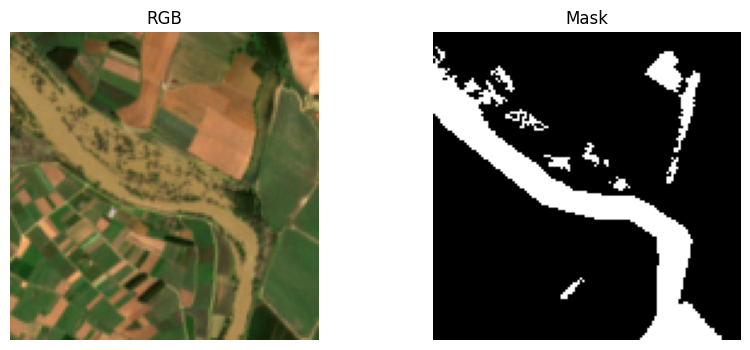

In [15]:
image, mask = train_dataset[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(
    image.permute(1,2,0)
)

plt.title("RGB")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    mask.squeeze(),
    cmap="gray"
)

plt.title("Mask")

plt.axis("off")

plt.show()

In [20]:
image.shape


torch.Size([3, 128, 128])

In [21]:
mask.shape

torch.Size([1, 128, 128])

## U-Net Building Blocks

Each encoder and decoder stage consists of:

Conv → ReLU → Conv → ReLU

In [22]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)

        )

    def forward(
        self,
        x
    ):

        return self.conv(x)

## Baseline U-Net

Architecture follows the STRUM implementation:

64 → 128 → 256 → 512 → 1024

In [23]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x
    ):

        # Encoder

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck

        b = self.bottleneck(p4)

        # Decoder

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.final(d1)

In [24]:
model = UNet().to(DEVICE)

print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (poo

In [25]:
x = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    y = model(x)

print(y.shape)

torch.Size([1, 1, 128, 128])


In [26]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 31,031,745
Trainable Parameters: 31,031,745


### Baseline U-Net Architecture

Input:
(3,128,128)

Encoder:

64 → 128 → 256 → 512

Bottleneck:

1024

Decoder:

512 → 256 → 128 → 64

Output:

(1,128,128)

Trainable Parameters:
[record value]

In [27]:
print(y.shape)

torch.Size([1, 1, 128, 128])


In [28]:
print(total_params)

31031745
